In [1]:
import pandas as pd
import sqlite3

# import plotly.express as px
import plotly.graph_objects as go
import get_rates

In [2]:
get_rates.get_rates(rebase=False)

In [3]:
conn = sqlite3.connect("rates.sqlite")

sql_str: str = """SELECT Exc_date, Currency, Exc_rate
FROM rates
WHERE Exc_date >= (SELECT DATE(MAX(Exc_date), '-90 day')
FROM rates)"""

df = pd.read_sql(sql_str, conn)
df.columns = ["Date", "Currency", "Rate"]


In [4]:
dfa = df.pivot_table(index="Date", columns="Currency", values="Rate", aggfunc="mean")
dfa.reset_index(inplace=True)
dfa["Date"] = pd.to_datetime(dfa["Date"])

dfa["EUR"] = dfa["HUF"] / dfa["EUR"]
dfa["USD"] = dfa["HUF"] / dfa["USD"]
dfa["CZK"] = dfa["HUF"] / dfa["CZK"]

In [6]:
dfa["a30EUR"] = dfa["EUR"].rolling(window=30).mean()
dfa["a30USD"] = dfa["USD"].rolling(window=30).mean()
dfa["a30CZK"] = dfa["CZK"].rolling(window=30).mean()

dfa["a15EUR"] = dfa["EUR"].rolling(window=15).mean()
dfa["a15USD"] = dfa["USD"].rolling(window=15).mean()
dfa["a15CZK"] = dfa["CZK"].rolling(window=15).mean()

dfa["EUR_10"] = dfa["EUR"].quantile(0.1)
dfa["EUR_90"] = dfa["EUR"].quantile(0.9)
dfa["USD_10"] = dfa["USD"].quantile(0.1)
dfa["USD_90"] = dfa["USD"].quantile(0.9)
dfa["CZK_10"] = dfa["CZK"].quantile(0.1)
dfa["CZK_90"] = dfa["CZK"].quantile(0.9)

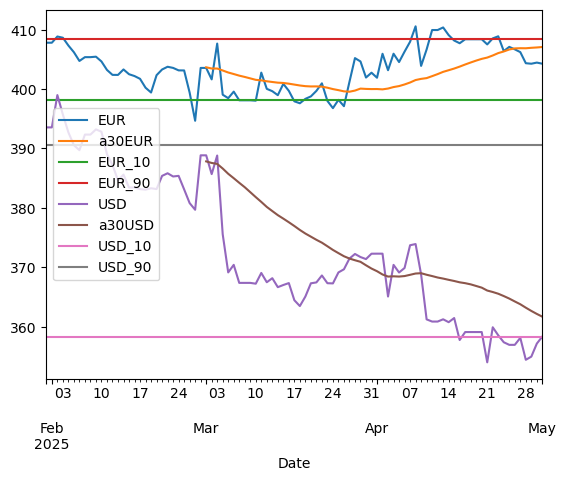

In [7]:
dfa.plot(
    kind="line",
    x="Date",
    y=["EUR", "a30EUR", "EUR_10", "EUR_90", "USD", "a30USD", "USD_10", "USD_90"],
).legend(loc="center left")


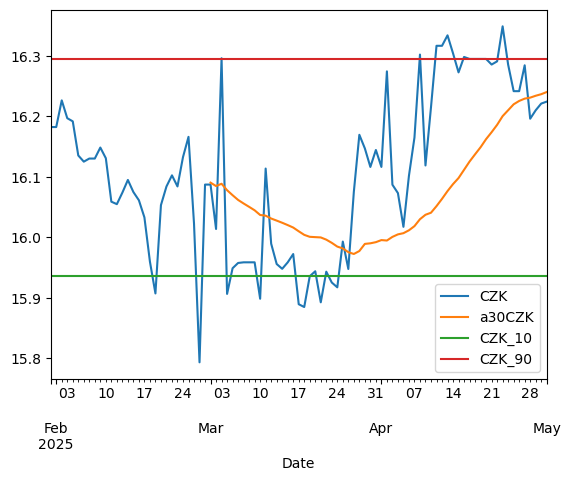

In [8]:
ax = dfa.plot(kind="line", x="Date", y=["CZK", "a30CZK", "CZK_10", "CZK_90"]).legend(
    loc="best"
)


In [9]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=dfa["Date"],
        y=dfa["EUR"],
        line=dict(color="firebrick", width=2),
        mode="lines",
        name="EUR",
    )
)
fig.add_trace(
    go.Scatter(
        x=dfa["Date"],
        y=dfa["a30EUR"],
        line=dict(color="firebrick", width=4),
        mode="lines",
        name="EUR30",
    )
)
fig.add_trace(
    go.Scatter(
        x=dfa["Date"],
        y=dfa["EUR_10"],
        line=dict(color="gray", width=1, dash="dash"),
        mode="lines",
        name="EUR_q10",
    )
)
fig.add_trace(
    go.Scatter(
        x=dfa["Date"],
        y=dfa["EUR_90"],
        line=dict(color="gray", width=1, dash="dash"),
        mode="lines",
        name="EUR_q90",
    )
)

fig.add_trace(
    go.Scatter(
        x=dfa["Date"],
        y=dfa["USD"],
        line=dict(color="royalblue", width=2),
        mode="lines",
        name="USD",
    )
)
fig.add_trace(
    go.Scatter(
        x=dfa["Date"],
        y=dfa["a30USD"],
        line=dict(color="royalblue", width=4),
        mode="lines",
        name="USD30",
    )
)
fig.add_trace(
    go.Scatter(
        x=dfa["Date"],
        y=dfa["USD_10"],
        line=dict(color="gray", width=1, dash="dash"),
        mode="lines",
        name="USD_q10",
    )
)
fig.add_trace(
    go.Scatter(
        x=dfa["Date"],
        y=dfa["USD_90"],
        line=dict(color="gray", width=1, dash="dash"),
        mode="lines",
        name="USD_q90",
    )
)

fig.show()